In [26]:
try:
    import ipywidgets as widgets
    from IPython.display import clear_output
    widgets_available = True
except ImportError:
    widgets_available = False

DERMATOSCOPY_IMAGE_OPTIONS = {
    "Superficial spreading melanoma (SSM21)": Path("./data/skin_cancer/melanoma/dermIS/SSM21_orig.jpg"),
    "Lentigo maligna melanoma (LMM2)": Path("./data/skin_cancer/melanoma/dermIS/LMM2_orig.jpg"),
    "Nodular melanoma (NM4)": Path("./data/skin_cancer/melanoma/dermIS/NM4_orig.jpg"),
}

HISTOPATHOLOGY_IMAGE_OPTIONS = {
    "Patch 0001": Path("./data/processed-original-monuseg/train_folder/img/0001.png"),
    "Patch 0008": Path("./data/processed-original-monuseg/train_folder/img/0008.png"),
    "Patch 0016": Path("./data/processed-original-monuseg/train_folder/img/0016.png"),
}

selected_dermatoscopy_path = next(iter(DERMATOSCOPY_IMAGE_OPTIONS.values()))
selected_histopathology_path = next(iter(HISTOPATHOLOGY_IMAGE_OPTIONS.values()))


def show_selected_demo_images() -> None:
    print(f"Dermatoscopy selection: {selected_dermatoscopy_path.name}")
    display(Image.open(selected_dermatoscopy_path))
    print(f"Histopathology selection: {selected_histopathology_path.name}")
    display(Image.open(selected_histopathology_path))


if widgets_available:
    derm_dropdown = widgets.Dropdown(
        options=[(label, str(path)) for label, path in DERMATOSCOPY_IMAGE_OPTIONS.items()],
        value=str(selected_dermatoscopy_path),
        description="Dermatoscopy:",
        layout=widgets.Layout(width="520px"),
    )
    hist_dropdown = widgets.Dropdown(
        options=[(label, str(path)) for label, path in HISTOPATHOLOGY_IMAGE_OPTIONS.items()],
        value=str(selected_histopathology_path),
        description="Histopath:",
        layout=widgets.Layout(width="520px"),
    )
    selector_output = widgets.Output()

    def on_selection_change(*_) -> None:
        global selected_dermatoscopy_path, selected_histopathology_path
        selected_dermatoscopy_path = Path(derm_dropdown.value)
        selected_histopathology_path = Path(hist_dropdown.value)
        with selector_output:
            clear_output(wait=True)
            show_selected_demo_images()
            print("Rerun the corresponding analysis cells to generate a new MedGemma report for the selected images.")

    derm_dropdown.observe(on_selection_change, names="value")
    hist_dropdown.observe(on_selection_change, names="value")
    on_selection_change()

    display(widgets.VBox([derm_dropdown, hist_dropdown, selector_output]))
else:
    print("ipywidgets is not available in this kernel, so the notebook is using the default demo images.")
    show_selected_demo_images()

# Skin cancer detection with MedGemma

This notebook demonstrates an AI-assisted dermatoscopic skin lesion workflow using a locally hosted `medgemma-1.5-4b-it` model exposed through the LM Studio OpenAI-compatible API.

The workflow is:
1. Load and display a dermatoscopic image.
2. Build a structured dermatology analysis prompt.
3. Send the image and prompt to MedGemma.
4. Capture and display the generated clinical-style report.


---
### Dermatoscopic image:

A **dermatoscopic image** (or dermoscopic image) is a highly specialized, magnified photograph of a skin lesion. 

While a standard "clinical" photograph shows what the eye sees, a dermatoscopic image uses a device called a **dermatoscope** to look *beneath* the surface of the skin (the stratum corneum).

#### 1. How It Works: The Physics of "Deep Seeing"
The main hurdle to seeing into the skin is light reflection. Our skin reflects most light, making it opaque. A dermatoscope solves this using two methods:
* **Polarized Light:** Modern dermatoscopes use cross-polarized filters to cancel out reflected light, allowing the lens to capture light returning from the deeper epidermis and papillary dermis.
* **Immersion Fluid:** Older "contact" methods involve placing a drop of oil or gel on the skin and pressing a glass plate against it. This "links" the skin to the lens and eliminates surface reflection.

#### 2. Clinical vs. Dermatoscopic
| Feature | Clinical Image (Phone/Camera) | Dermatoscopic Image |
| :--- | :--- | :--- |
| **Visible Depth** | Surface only | Epidermis & superficial dermis |
| **Magnification** | 1x (Variable) | 10x to 40x |
| **Key Indicators** | Color, borders, size | Pigment networks, vascular patterns |
| **Reflections** | High (Shiny skin) | None (Polarized/Fluid neutralized) |

#### 3. Usage in Cancer Detection
Dermatologists use these images to look for specific patterns that are invisible to the naked eye.
Dermatoscopic images represent one of the most successful use cases for Medical AI today:

* **The ISIC Challenge:** The "International Skin Imaging Collaboration" (ISIC) provides massive open-source datasets of these images. Most top-tier skin cancer AI models (using architectures like EfficientNet or Vision Transformers) are trained specifically on these dermatoscopic images rather than standard photos.

---

## Runtime configuration

The notebook uses the LM Studio OpenAI-compatible chat endpoint. By default it calls:

- LM_STUDIO_BASE_URL = http://192.168.1.2:1234/v1
- LM_STUDIO_MODEL = medgemma-1.5-4b-it

If your Windows host IP changes, set the LM_STUDIO_BASE_URL environment variable or update the value in the configuration cell before running the API request.

In [27]:
import base64
import mimetypes
import os
from pathlib import Path

import requests
from PIL import Image
from IPython.display import Markdown, display

Dermatological photograph taken with a standard consumer-grade camera.


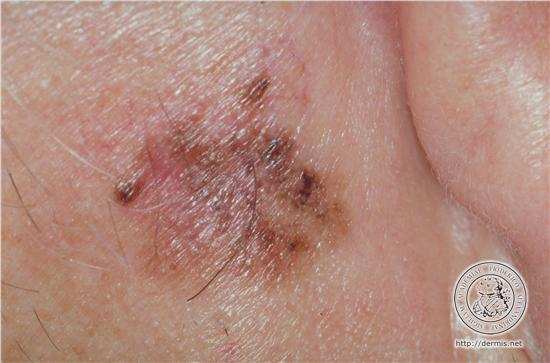

Image path: data/skin_cancer/melanoma/dermIS/LMM2_orig.jpg
Image size: 550 x 363
LM Studio endpoint: http://192.168.1.2:1234/v1
Model: medgemma-1.5-4b-it


In [28]:
LM_STUDIO_BASE_URL = os.getenv("LM_STUDIO_BASE_URL", "http://192.168.1.2:1234/v1")
LM_STUDIO_MODEL = os.getenv("LM_STUDIO_MODEL", "medgemma-1.5-4b-it")

default_dermatoscopy_path = Path("./data/skin_cancer/melanoma/dermIS/SSM21_orig.jpg")
image_path = globals().get("selected_dermatoscopy_path", default_dermatoscopy_path)
if not image_path.exists():
    raise FileNotFoundError(f"Image not found: {image_path.resolve()}")

image = Image.open(image_path)
print("Dermatological photograph taken with a standard consumer-grade camera.")
display(image)

print(f"Image path: {image_path}")
print(f"Image size: {image.size[0]} x {image.size[1]}")
print(f"LM Studio endpoint: {LM_STUDIO_BASE_URL}")
print(f"Model: {LM_STUDIO_MODEL}")

In [29]:
prompt = """
You are an expert dermatology decision-support model reviewing a dermatoscopic skin lesion image.

Analyze the lesion and produce a concise clinician-facing report with these sections:

1. Visual findings
- Describe asymmetry, border regularity, color variation, and visible dermoscopic structures.

2. Most likely diagnosis
- Choose the single best fit from:
  - Melanoma
  - Melanocytic Nevus
  - Basal Cell Carcinoma
  - Actinic Keratosis / Bowen's Disease
  - Benign Keratosis
  - Dermatofibroma
  - Vascular Lesion

3. Diagnostic rationale
- Explain why the selected diagnosis is the best match based on the image.

4. Clinical caution
- State the main uncertainty or limitation of image-only assessment.

Keep the tone professional and medically precise. Do not overstate certainty. Make clear that this is decision support and not a confirmed diagnosis.
""".strip()

print(prompt)

You are an expert dermatology decision-support model reviewing a dermatoscopic skin lesion image.

Analyze the lesion and produce a concise clinician-facing report with these sections:

1. Visual findings
- Describe asymmetry, border regularity, color variation, and visible dermoscopic structures.

2. Most likely diagnosis
- Choose the single best fit from:
  - Melanoma
  - Melanocytic Nevus
  - Basal Cell Carcinoma
  - Actinic Keratosis / Bowen's Disease
  - Benign Keratosis
  - Dermatofibroma
  - Vascular Lesion

3. Diagnostic rationale
- Explain why the selected diagnosis is the best match based on the image.

4. Clinical caution
- State the main uncertainty or limitation of image-only assessment.

Keep the tone professional and medically precise. Do not overstate certainty. Make clear that this is decision support and not a confirmed diagnosis.


In [30]:
def encode_image_to_data_url(path: Path) -> str:
    mime_type, _ = mimetypes.guess_type(path.name)
    mime_type = mime_type or "image/jpeg"

    with path.open("rb") as image_file:
        encoded_image = base64.b64encode(image_file.read()).decode("utf-8")

    return f"data:{mime_type};base64,{encoded_image}"


def build_messages(user_prompt: str, image_data_url: str) -> list[dict]:
    return [
        {
            "role": "system",
            "content": "You are a careful multimodal medical assistant that produces concise specialist-style reports from clinical images."
        },
        {
            "role": "user",
            "content": [
                {"type": "text", "text": user_prompt},
                {"type": "image_url", "image_url": {"url": image_data_url}}
            ]
        }
    ]


print("Shared LM Studio multimodal helpers are ready.")

Shared LM Studio multimodal helpers are ready.


In [31]:
image_data_url = encode_image_to_data_url(image_path)
messages = build_messages(prompt, image_data_url)

payload = {
    "model": LM_STUDIO_MODEL,
    "messages": messages,
    "temperature": 0.2,
    "max_tokens": 700,
}

response = requests.post(
    f"{LM_STUDIO_BASE_URL}/chat/completions",
    json=payload,
    timeout=120,
)
response.raise_for_status()

response_json = response.json()
assistant_message = response_json["choices"][0]["message"]["content"]

if isinstance(assistant_message, list):
    assistant_message = "\n".join(
        part.get("text", "") for part in assistant_message if part.get("type") == "text"
    ).strip()

report_markdown = "\n".join([
    "## MedGemma Clinical Report",
    "",
    f"**Image:** `{image_path.name}`",
    "",
    assistant_message,
])

display(Markdown(report_markdown))

## MedGemma Clinical Report

**Image:** `LMM2_orig.jpg`

FINDINGS: The lesion exhibits asymmetry in shape and structure. The borders are irregular, with some areas appearing notched or ill-defined. Color variation is present, including shades of brown, tan, and pinkish hues. Dermoscopic structures include an atypical pigment network, irregular dots/globules, and possibly regression features (lighter areas).

DIAGNOSIS: Melanocytic Nevus

RATIONALE: The presence of a pigment network, although somewhat irregular, along with dots/globules is consistent with a melanocytic lesion. While some asymmetry and color variation are noted, the overall pattern leans towards a benign nevus rather than features strongly suggestive of melanoma or other malignancy in this single image.

CAUTION: Image-only assessment carries inherent limitations. Clinical correlation, including patient history and physical examination findings, is essential for accurate diagnosis.

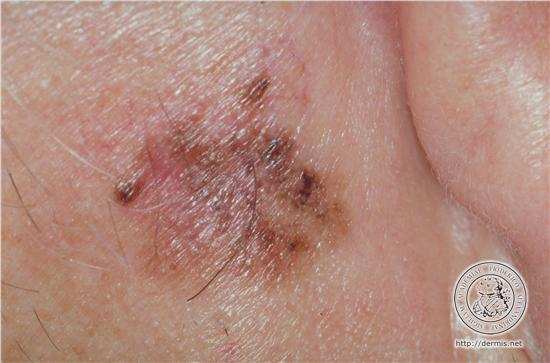

In [32]:
display(image)

## AI powered cancer detection using histopathology images

Histopathology images are high-resolution digital captures of thin slices of biological tissue that have been chemically stained and placed on glass slides. While a scan (like an MRI or CT) looks at the "macro" structure of the body, histopathology looks at the cellular level. In the medical world, a histopathology report is considered the "Gold Standard" for diagnosing cancer.

### 1. How the Images are Created
The process of moving from a patient to a digital image involves several steps:
* **Biopsy:** A small piece of tissue is removed from the patient.
* **Fixation and Slicing:** The tissue is hardened (usually in paraffin wax) and cut into slices thinner than a human hair (about 4–5 microns).
* **Staining (H&E):** The slices are clear, so they are dyed with **Hematoxylin** (which turns cell nuclei deep blue/purple) and **Eosin** (which turns the rest of the cell structures pink/red).
* **Digitization:** A Whole Slide Imaging (WSI) scanner captures these slides at 20x or 40x magnification, creating massive image files (often several gigabytes each).

### 2. How They Are Used for Cancer Detection
Pathologists (and increasingly, AI models) analyze these images to find structural "clues" that indicate malignancy:

#### **Cellular Abnormality**
In healthy tissue, cells are uniform. In cancer, cells often have:
* **Large, irregular nuclei:** The "brain" of the cell becomes enlarged and dark.
* **Increased Mitosis:** You can see cells in the middle of dividing, indicating rapid, uncontrolled growth.

#### **Tissue Architecture**
Cancer disrupts the natural "neighborhood" of cells. 
* **Infiltration:** Instead of staying within their boundary (like the lining of a duct), cancer cells break through and invade surrounding healthy tissue.
* **Loss of Differentiation:** High-grade cancer cells look nothing like the original tissue they came from; they become a chaotic "sheet" of cells.

### 3. The Role of AI and ML (Computational Pathology)
As an AI/ML engineer, this is where the field gets exciting. Because these images are so large ($50,000 \times 50,000$ pixels or more), humans can miss tiny "micrometastases." 

* **Patch-Based Classification:** Since the images are too big for a standard GPU's VRAM, they are broken into smaller "patches" (e.g., $224 \times 224$). A CNN or Transformer model classifies each patch as "Tumor" or "Normal."
* **Automated Grading:** AI can quantify exactly how many mitotic cells are present or measure the surface area of a tumor more accurately than a human eye.
* **Segmentation:** Drawing precise boundaries around a tumor helps surgeons or radiologists plan treatments.

#### Comparison: Radiology vs. Histopathology

| Feature | Radiology (CT/MRI/X-ray) | Histopathology (WSI) |
| :--- | :--- | :--- |
| **View** | Macroscopic (Organs/Bones) | Microscopic (Cells) |
| **Purpose** | Locate a mass or abnormality | Determine if the mass is cancerous |
| **Magnification** | 1x | 20x to 40x |
| **Data Format** | DICOM | SVS, TIFF, NDPI |

## Histopathology image analysis with MedGemma

This section mirrors the dermatoscopic workflow, but uses a histopathology slide patch. The notebook will:

1. Load a sample histopathology image.
2. Send the image and a pathology-focused prompt to MedGemma.
3. Render the returned report in the notebook.

### Interactive demo selector

Use the selector below to switch between a few prepared dermatoscopy and histopathology examples before rerunning the analysis cells.

This makes the notebook easier to present live because you can show that the same MedGemma workflow generalizes across:

- lesion-surface analysis in dermatoscopy
- cellular and tissue-pattern analysis in histopathology

Histopathology image patch from the MoNuSeg-style dataset.


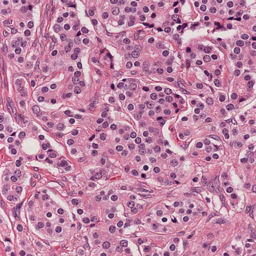

Image path: data/processed-original-monuseg/train_folder/img/0016.png
Image size: 256 x 256


In [34]:
default_histopathology_path = Path("./data/processed-original-monuseg/train_folder/img/0001.png")
histopathology_image_path = globals().get("selected_histopathology_path", default_histopathology_path)
if not histopathology_image_path.exists():
    raise FileNotFoundError(f"Image not found: {histopathology_image_path.resolve()}")

histopathology_image = Image.open(histopathology_image_path)
print("Histopathology image patch from the MoNuSeg-style dataset.")
display(histopathology_image)
print(f"Image path: {histopathology_image_path}")
print(f"Image size: {histopathology_image.size[0]} x {histopathology_image.size[1]}")

In [ ]:
histopathology_prompt = """
You are an expert pathology decision-support model reviewing a histopathology image patch.

Analyze the image and produce a concise clinician-facing pathology-style report with these sections:

1. Microscopic findings
- Describe the dominant cell morphology, nuclear appearance, staining characteristics, cell density, tissue architecture, and any visible glandular, 
stromal, inflammatory, necrotic, or mitotic features.

2. Most likely interpretation
- State the single best interpretation of the tissue pattern or abnormality visible in the patch.
- If the image suggests malignancy, say whether the appearance is suspicious for malignant change.

3. Diagnostic rationale
- Explain which visual features support the interpretation.

4. Differential considerations
- List one or two plausible alternative interpretations if the appearance is not specific.

5. Clinical caution
- State the main limitation of making a diagnosis from one image patch alone and mention that definitive diagnosis requires full-slide review and pathologist correlation.

Keep the tone professional and medically precise. Do not overstate certainty. Distinguish observed morphology from inferred diagnosis.
""".strip()

print(histopathology_prompt)

You are an expert pathology decision-support model reviewing a histopathology image patch.

Analyze the image and produce a concise clinician-facing pathology-style report with these sections:

1. Microscopic findings
- Describe the dominant cell morphology, nuclear appearance, staining characteristics, cell density, tissue architecture, and any visible glandular, stromal, inflammatory, necrotic, or mitotic features.

2. Most likely interpretation
- State the single best interpretation of the tissue pattern or abnormality visible in the patch.
- If the image suggests malignancy, say whether the appearance is suspicious for malignant change.

3. Diagnostic rationale
- Explain which visual features support the interpretation.

4. Differential considerations
- List one or two plausible alternative interpretations if the appearance is not specific.

5. Clinical caution
- State the main limitation of making a diagnosis from one image patch alone and mention that definitive diagnosis require

In [36]:
histopathology_image_data_url = encode_image_to_data_url(histopathology_image_path)
histopathology_messages = build_messages(histopathology_prompt, histopathology_image_data_url)

histopathology_payload = {
    "model": LM_STUDIO_MODEL,
    "messages": histopathology_messages,
    "temperature": 0.2,
    "max_tokens": 900,
}

histopathology_response = requests.post(
    f"{LM_STUDIO_BASE_URL}/chat/completions",
    json=histopathology_payload,
    timeout=120,
)
histopathology_response.raise_for_status()

histopathology_response_json = histopathology_response.json()
histopathology_assistant_message = histopathology_response_json["choices"][0]["message"]["content"]

if isinstance(histopathology_assistant_message, list):
    histopathology_assistant_message = "\n".join(
        part.get("text", "")
        for part in histopathology_assistant_message
        if part.get("type") == "text"
    ).strip()

histopathology_report_markdown = "\n".join([
    "## MedGemma Histopathology Report",
    "",
    f"**Image patch:** `{histopathology_image_path.name}`",
    "",
    histopathology_assistant_message,
])

display(Markdown(histopathology_report_markdown))

## MedGemma Histopathology Report

**Image patch:** `0016.png`

FINDINGS: The image displays a dense proliferation of cells with round to oval nuclei, some exhibiting prominent nucleoli. The nuclear chromatin appears relatively uniform in staining. Cells are arranged in sheets and nests, with limited stromal component visible. No significant necrosis or mitotic activity is readily apparent within the field of view.

IMPRESSION: Dense cellular proliferation consistent with carcinoma.

RATIONALE: The presence of numerous cells with round nuclei, nucleoli, and a lack of significant glandular or stromal architecture strongly suggests a neoplastic process, specifically carcinoma.

DIFFERENTIAL CONSIDERATIONS: Benign proliferative lesions such as fibroadenoma could be considered but are less likely given the cellular atypia suggested by nuclear features.

CLINICAL CAUTION: This is a single image patch; correlation with additional sections and clinical context is required for definitive diagnosis.

## Comparing the two MedGemma diagnosis tasks

These two demos use the same multimodal API pattern, but they ask MedGemma to reason over very different visual evidence.

| Demo | What the model inspects | Typical cues in the prompt | Expected output style |
| :--- | :--- | :--- | :--- |
| Dermatoscopy | Surface lesion morphology | Asymmetry, borders, pigmentation, dermoscopic structures | Dermatology-style lesion assessment |
| Histopathology | Cellular morphology and tissue architecture | Nuclear atypia, mitoses, gland formation, tissue organization | Pathology-style microscopic report |

That contrast helps make the core demo point clear: one multimodal medical model can be steered toward different diagnostic reporting styles by changing both the image modality and the prompt structure.